In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score                


In [12]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DELL\Nassau Candy Distributor (2).csv")

print(df.shape)
print(df.columns)

(10194, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')


In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days.abs()

print(df['Lead Time'].head())
print(df.shape)

0    909
1    909
2    909
3    909
4    912
Name: Lead Time, dtype: int64
(10194, 19)


In [18]:
df = df.dropna(subset=['Lead Time'])
df.ffill(inplace=True)

print("After cleaning:", df.shape)

After cleaning: (10194, 19)


In [20]:
product_factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df['Product Name'] = df['Product Name'].astype(str).str.strip()
df['Factory'] = df['Product Name'].map(product_factory_map)

print("Missing Factory:", df['Factory'].isna().sum())

df = df.dropna(subset=['Factory'])

print("After mapping:", df.shape)

Missing Factory: 0
After mapping: (10194, 20)


In [22]:
df['Profit'] = df['Sales'] - df['Cost']

In [24]:
df['Product Original'] = df['Product Name'].copy()
df['Factory Original'] = df['Factory'].copy()

In [26]:
from sklearn.preprocessing import LabelEncoder

le_product = LabelEncoder()
le_factory = LabelEncoder()
le_ship = LabelEncoder()
le_region = LabelEncoder()

df['Product Name'] = le_product.fit_transform(df['Product Name'])
df['Factory'] = le_factory.fit_transform(df['Factory'])
df['Ship Mode'] = le_ship.fit_transform(df['Ship Mode'])
df['Region'] = le_region.fit_transform(df['Region'])

print(df.shape)

(10194, 23)


In [36]:
X = df[['Product Name', 'Factory', 'Ship Mode', 'Region', 'Units', 'Cost']]
y = df['Lead Time']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2:", r2_score(y_test, y_pred))

MAE: 214.11582977734605
RMSE: 266.8682155477446
R2: -0.019047208969887652


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [65]:
def simulate(product, factory):
    temp = df[df['Product Name'] == product].copy()
    temp['Factory'] = factory
    
    pred_lead = model.predict(temp[X.columns]).mean()
    
    current_lead = temp['Lead Time'].mean()
    avg_profit = temp['Profit'].mean()
    
    improvement = ((current_lead - pred_lead) / current_lead) * 100
    
    return pred_lead, avg_profit, improvement

In [61]:
products = df['Product Name'].unique()
factories = df['Factory'].unique()

results = []

for p in products:
    for f in factories:
        lead, profit, improvement = simulate(p, f)
        
        product_name = df[df['Product Name'] == p]['Product Original'].iloc[0]
        factory_name = df[df['Factory'] == f]['Factory Original'].iloc[0]
        
        confidence = model.score(X, y)
        
        # normalize values
        normalized_lead = 1 / (lead + 1)
        normalized_profit = profit / (df['Profit'].max() + 1)
        
        # scoring
        score = (0.5 * normalized_lead) + (0.3 * normalized_profit) + (0.2 * (improvement / 100))
        
        # rounding (IMPORTANT: same indent level)
        lead = round(lead, 2)
        profit = round(profit, 2)
        improvement = round(improvement, 2)
        score = round(score, 4)
        confidence = round(confidence, 4)
        
        results.append({
            "Product": product_name,
            "Factory": factory_name,
            "Predicted Lead Time": lead,
            "Profit": profit,
            "Lead Time Improvement (%)": improvement,
            "Confidence Score": confidence,
            "Score": score
        })

In [62]:
results_df = pd.DataFrame(results)

In [64]:
results_df = results_df.sort_values(by='Score', ascending=False)

print(results_df.head(10))

                   Product            Factory  Predicted Lead Time  Profit  \
38      Lickable Wallpaper  The Other Factory              1346.61   41.81   
35      Lickable Wallpaper    Wicked Choccy's              1347.28   41.81   
36      Lickable Wallpaper      Lot's O' Nuts              1347.98   41.81   
39      Lickable Wallpaper        Sugar Shack              1347.69   41.81   
37      Lickable Wallpaper     Secret Factory              1348.33   41.81   
65  Everlasting Gobstopper    Wicked Choccy's              1354.96   34.67   
69  Everlasting Gobstopper        Sugar Shack              1358.72   34.67   
68  Everlasting Gobstopper  The Other Factory              1360.07   34.67   
67  Everlasting Gobstopper     Secret Factory              1366.36   34.67   
66  Everlasting Gobstopper      Lot's O' Nuts              1367.75   34.67   

    Lead Time Improvement (%)  Confidence Score   Score  
38                      -0.56            0.0491  0.0950  
35                      -

In [70]:
best_recommendations = results_df.loc[
    results_df.groupby('Product')['Score'].idxmax()
]

print(best_recommendations)

                              Product            Factory  Predicted Lead Time  \
65             Everlasting Gobstopper    Wicked Choccy's              1354.96   
44               Fizzy Lifting Drinks        Sugar Shack              1307.17   
70                            Fun Dip    Wicked Choccy's              1296.56   
61                        Hair Toffee      Lot's O' Nuts              1375.46   
33                          Kazookles  The Other Factory              1277.49   
45                        Laffy Taffy    Wicked Choccy's              1383.59   
38                 Lickable Wallpaper  The Other Factory              1346.61   
59                              Nerds        Sugar Shack              1318.85   
50                          SweeTARTS    Wicked Choccy's              1327.85   
23          Wonka Bar - Fudge Mallows  The Other Factory              1312.27   
3          Wonka Bar - Milk Chocolate  The Other Factory              1317.28   
10  Wonka Bar - Nutty Crunch

In [72]:
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107)
}

In [74]:
region_coords = {
    0: (40, -100),
    1: (35, -80),
    2: (45, -120),
    3: (30, -90)
}

In [76]:
import math

def calculate_distance(factory, region):
    f_lat, f_lon = factory_coords[factory]
    r_lat, r_lon = region_coords.get(region, (40, -100))
    
    return math.sqrt((f_lat - r_lat)**2 + (f_lon - r_lon)**2)

In [80]:
def simulate(product, factory):
    temp = df[df['Product Name'] == product].copy()
    
    temp['Factory'] = factory
    
    pred_lead = model.predict(temp[X.columns]).mean()
    
    current_lead = temp['Lead Time'].mean()
    avg_profit = temp['Profit'].mean()
    
    improvement = ((current_lead - pred_lead) / current_lead) * 100
    factory_name = df[df['Factory'] == factory]['Factory Original'].iloc[0]
    region = temp['Region'].iloc[0]
    
    distance = calculate_distance(factory_name, region)
    
    return pred_lead, avg_profit, improvement, distance

In [82]:
lead, profit, improvement, distance = simulate(p, f)

In [84]:
normalized_distance = 1 / (distance + 1)

In [86]:
score = (
    0.4 * normalized_lead +
    0.3 * normalized_profit +
    0.2 * (improvement / 100) +
    0.1 * normalized_distance
)

In [90]:
print("Average Lead Time:", results_df['Predicted Lead Time'].mean())
print("Average Improvement:", results_df['Lead Time Improvement (%)'].mean())
print("Best Score:", results_df['Score'].max())

Average Lead Time: 1329.7073333333333
Average Improvement: 0.0014666666666667183
Best Score: 0.095


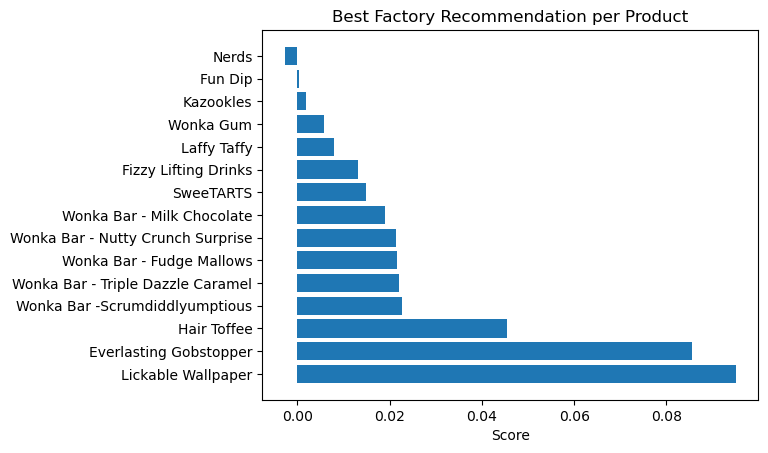

In [98]:
import matplotlib.pyplot as plt

top_products = best_recommendations.sort_values(by='Score', ascending=False)

plt.figure()
plt.barh(top_products['Product'], top_products['Score'])
plt.xlabel("Score")
plt.title("Best Factory Recommendation per Product")
plt.show()

In [94]:
best_recommendations = results_df.loc[
    results_df.groupby('Product')['Score'].idxmax()
]

print(best_recommendations)

                              Product            Factory  Predicted Lead Time  \
65             Everlasting Gobstopper    Wicked Choccy's              1354.96   
44               Fizzy Lifting Drinks        Sugar Shack              1307.17   
70                            Fun Dip    Wicked Choccy's              1296.56   
61                        Hair Toffee      Lot's O' Nuts              1375.46   
33                          Kazookles  The Other Factory              1277.49   
45                        Laffy Taffy    Wicked Choccy's              1383.59   
38                 Lickable Wallpaper  The Other Factory              1346.61   
59                              Nerds        Sugar Shack              1318.85   
50                          SweeTARTS    Wicked Choccy's              1327.85   
23          Wonka Bar - Fudge Mallows  The Other Factory              1312.27   
3          Wonka Bar - Milk Chocolate  The Other Factory              1317.28   
10  Wonka Bar - Nutty Crunch